<a href="https://colab.research.google.com/github/radmm/colab-notebook-01/blob/main/kimi_k2_6_nvidia_nim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌙 Kimi K2.6 — Image & Video Analysis via NVIDIA NIM
> **Model:** `moonshotai/kimi-k2.6`  
> **API:** NVIDIA NIM `https://integrate.api.nvidia.com/v1`  
> **Key:** Free with NVIDIA Developer Program → [build.nvidia.com](https://build.nvidia.com/moonshotai/kimi-k2.6)

---
### How to get your free NVIDIA API key
1. Go to [build.nvidia.com/moonshotai/kimi-k2.6](https://build.nvidia.com/moonshotai/kimi-k2.6)
2. Sign in / create a free NVIDIA Developer account
3. Click **Get API Key** → copy it
4. Paste into Cell 2 below

### Notebook structure
| Section | What it does |
|---|---|
| Cell 1 | Install deps |
| Cell 2 | Setup client + helpers |
| **A1** | Image from public URL |
| **A2** | Upload local image (Colab picker) |
| **A3** | Multi-image comparison |
| **B1** | Video → extract frames → analyse (upload local video) |
| **B2** | Video from YouTube/URL → download → frame extract → analyse |

> ℹ️ **Why frames for video?** NVIDIA NIM serves images natively. Kimi's native video endpoint only exists on Moonshot's own API. Frame extraction is the correct approach for NIM and gives you full control over which moments the model reasons about.

## ⚙️ Cell 1 — Install Dependencies

In [2]:
# Cell 1: Install packages
!pip install openai requests Pillow opencv-python-headless -q
print("✅ All dependencies installed.")

✅ All dependencies installed.


## 🔑 Cell 2 — API Key & Client Setup

In [1]:
# Cell 2: Configure NVIDIA NIM client for Kimi K2.6
import os, base64, io, requests
import cv2
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
from openai import OpenAI
from IPython.display import display, Image as IPImage, Markdown

# ── Paste your NVIDIA API key here ────────────────────────────────────────────
NVIDIA_API_KEY = "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"   # 👈 Replace this
# ──────────────────────────────────────────────────────────────────────────────

MODEL    = "moonshotai/kimi-k2.6"
BASE_URL = "https://integrate.api.nvidia.com/v1"

client = OpenAI(
    api_key=NVIDIA_API_KEY,
    base_url=BASE_URL,
)

def make_request(messages, thinking=True, max_tokens=4096, stream=False):
    """Send a request to Kimi K2.6 via NVIDIA NIM.
    thinking=True  → reasoning mode ON  (default on NIM)
    thinking=False → instant mode, faster responses
    """
    kwargs = dict(
        model=MODEL,
        messages=messages,
        max_tokens=max_tokens,
        stream=stream,
    )
    if not thinking:
        # NIM uses chat_template_kwargs to toggle thinking
        kwargs["extra_body"] = {"chat_template_kwargs": {"thinking": False}}
    else:
        kwargs["temperature"] = 1.0
        kwargs["top_p"]       = 0.95
    return client.chat.completions.create(**kwargs)

def print_response(response, show_reasoning=True):
    """Pretty-print response and optional reasoning trace."""
    msg       = response.choices[0].message
    reasoning = getattr(msg, "reasoning_content", None) or getattr(msg, "reasoning", None)
    if show_reasoning and reasoning:
        display(Markdown("### 🧠 Reasoning Trace"))
        preview = reasoning[:1500] + ("\n...[truncated]" if len(reasoning) > 1500 else "")
        print(preview)
        print()
    display(Markdown("### 💬 Model Response"))
    print(msg.content)
    u = response.usage
    print(f"\n📊 Tokens — prompt: {u.prompt_tokens} | completion: {u.completion_tokens} | total: {u.total_tokens}")

def pil_to_b64(img: PILImage.Image, fmt="JPEG") -> str:
    """Convert a PIL image to base64 data URI."""
    buf = io.BytesIO()
    img.save(buf, format=fmt)
    b64 = base64.b64encode(buf.getvalue()).decode()
    mime = "image/jpeg" if fmt == "JPEG" else "image/png"
    return f"data:{mime};base64,{b64}"

def bytes_to_b64_uri(raw: bytes, ext: str) -> str:
    """Convert raw bytes to base64 data URI given a file extension."""
    mime = {"jpg": "image/jpeg", "jpeg": "image/jpeg",
            "png": "image/png",  "webp": "image/webp",
            "gif": "image/gif"}.get(ext.lower(), "image/jpeg")
    b64 = base64.b64encode(raw).decode()
    return f"data:{mime};base64,{b64}"

print(f"✅ Client ready")
print(f"   Model : {MODEL}")
print(f"   API   : {BASE_URL}")

✅ Client ready
   Model : moonshotai/kimi-k2.6
   API   : https://integrate.api.nvidia.com/v1


---
## 🖼️ SECTION A — Image Analysis
Supported formats: **GIF · JPG · JPEG · PNG** · Up to 4 images per request by default

### A1 · Analyse an image from a public URL

In [3]:
# Cell A1: Analyse a remote image by URL
# ── CONFIG ─────────────────────────────────────────────────────────────────────
IMAGE_URL = "https://assets.ngc.nvidia.com/products/api-catalog/phi-3-5-vision/example1b.jpg"
PROMPT    = "Describe this image in detail. Identify all objects, people, colours, text, and the overall scene."
THINKING  = True    # True = reasoning mode | False = instant (faster)
# ──────────────────────────────────────────────────────────────────────────────

# Preview
display(IPImage(url=IMAGE_URL, width=450))

messages = [
    {
        "role": "user",
        "content": [
            {"type": "text",      "text": PROMPT},
            {"type": "image_url", "image_url": {"url": IMAGE_URL}},
        ],
    }
]

print(f"🔍 Sending to Kimi K2.6 via NVIDIA NIM | Thinking: {THINKING}\n")
response = make_request(messages, thinking=THINKING)
print_response(response)

🔍 Sending to Kimi K2.6 via NVIDIA NIM | Thinking: True



### 💬 Model Response

 I need to describe this image in detail, identifying all elements present.

## Overall Scene
This is a bright, serene landscape photograph capturing a **wooden boardwalk/pathway** stretching through a lush **grassland or meadow** toward the horizon under a vast, partly cloudy sky. The scene evokes tranquility, openness, and natural beauty, likely depicting a wetland, prairie, or nature reserve environment.

---

## Objects and Elements

### Foreground & Midground
- **Wooden boardwalk** – weathered gray-brown planks running vertically through the center of the image, creating strong perspective leading to the horizon; wooden edges/frame visible along the sides
- **Tall green grass** – dense, vibrant blades/flourishing vegetation on both sides of the pathway; appears to be wild grasses or reeds, varying in height
- **Brownish-orange shrubs/bushes** – visible to the right side in the midground, adding color variation and suggesting seasonal change (perhaps early autumn) or different plan

### A2 · Upload & analyse a local image

In [ ]:
# Cell A2: Upload a local image from your device
from google.colab import files as colab_files

# ── CONFIG ─────────────────────────────────────────────────────────────────────
PROMPT   = "Analyse this image thoroughly. Describe what you see in detail."
THINKING = True
# ──────────────────────────────────────────────────────────────────────────────

print("📁 Select an image file (JPG / PNG / GIF / WEBP)...")
uploaded = colab_files.upload()

if not uploaded:
    print("⚠️  No file uploaded.")
else:
    fname = next(iter(uploaded))
    raw   = uploaded[fname]
    ext   = fname.rsplit(".", 1)[-1]

    # Preview
    img = PILImage.open(io.BytesIO(raw))
    display(img.resize((min(img.width, 480), int(img.height * min(480/img.width, 1)))))
    print(f"\n📐 {img.size[0]}×{img.size[1]} px  |  {fname}")

    data_uri = bytes_to_b64_uri(raw, ext)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text",      "text": PROMPT},
                {"type": "image_url", "image_url": {"url": data_uri}},
            ],
        }
    ]

    print(f"\n🔍 Analysing '{fname}' | Thinking: {THINKING}\n")
    response = make_request(messages, thinking=THINKING)
    print_response(response)

### A3 · Multi-image comparison

In [ ]:
# Cell A3: Send two images in one prompt and compare them
# ── CONFIG ─────────────────────────────────────────────────────────────────────
IMAGE_URL_1 = "https://assets.ngc.nvidia.com/products/api-catalog/phi-3-5-vision/example1b.jpg"
IMAGE_URL_2 = "https://www.nvidia.com/content/dam/en-zz/Solutions/data-center/dgx-b200/dgx-b200-hero-bm-v2-l580-d.jpg"
PROMPT      = "Compare these two images. What are the key differences and similarities in subject matter, style, and composition? Be specific."
THINKING    = False   # instant mode for speed
# ──────────────────────────────────────────────────────────────────────────────

print("Image 1:")
display(IPImage(url=IMAGE_URL_1, width=350))
print("Image 2:")
display(IPImage(url=IMAGE_URL_2, width=350))

messages = [
    {
        "role": "user",
        "content": [
            {"type": "text",      "text": PROMPT},
            {"type": "image_url", "image_url": {"url": IMAGE_URL_1}},
            {"type": "image_url", "image_url": {"url": IMAGE_URL_2}},
        ],
    }
]

print(f"\n🔍 Comparing 2 images | Thinking: {THINKING}\n")
response = make_request(messages, thinking=THINKING)
print_response(response, show_reasoning=False)

---
## 🎬 SECTION B — Video Analysis (Frame Extraction Method)
> NVIDIA NIM serves image inputs. For video, we extract evenly-spaced keyframes using OpenCV,  
> then send them as a multi-image prompt. This is the correct approach for NIM and gives you  
> fine-grained control over which moments get analysed.
>
> **Tip:** 8–12 frames covers most short clips well. Bump up for longer videos.

### Frame Extractor Helper (run once)

In [5]:
# Frame extraction helper — run this before B1 or B2
import cv2
from IPython.display import display
from PIL import Image as PILImage
import io, base64

def extract_frames(video_path: str, n_frames: int = 10, max_dim: int = 720) -> list:
    """
    Extract n evenly-spaced frames from a video file.
    Returns list of base64 data URIs (JPEG).
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    duration_s   = total_frames / fps if fps > 0 else 0
    print(f"📹 Video info — frames: {total_frames} | FPS: {fps:.1f} | duration: {duration_s:.1f}s")

    indices = [int(i * total_frames / n_frames) for i in range(n_frames)]
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        # BGR → RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = PILImage.fromarray(frame_rgb)

        # Resize if too large
        w, h = img.size
        if max(w, h) > max_dim:
            scale = max_dim / max(w, h)
            img   = img.resize((int(w*scale), int(h*scale)), PILImage.LANCZOS)

        frames.append(pil_to_b64(img, "JPEG"))

    cap.release()
    print(f"✅ Extracted {len(frames)} frames")
    return frames


def preview_frames(frames: list, cols: int = 5):
    """Display extracted frames as a quick visual preview."""
    display(Markdown(f"#### 🎞️ Extracted {len(frames)} frames:"))
    for i, uri in enumerate(frames):
        b64data = uri.split(",", 1)[1]
        raw     = base64.b64decode(b64data)
        img     = PILImage.open(io.BytesIO(raw))
        display(img.resize((200, int(img.height * 200 / img.width))))


def build_video_messages(frames: list, prompt: str) -> list:
    """Build multi-image message payload from extracted frames."""
    content = [{"type": "text", "text": prompt}]
    for uri in frames:
        content.append({"type": "image_url", "image_url": {"url": uri}})
    return [{"role": "user", "content": content}]


print("✅ Frame extractor helper ready.")

✅ Frame extractor helper ready.


### B1 · Upload a local video and analyse it

📁 Select a video file (MP4 / MOV / AVI recommended)...


Saving clip.mp4 to clip (2).mp4

💾 Saved: clip (2).mp4  (1.20 MB)
📹 Video info — frames: 263 | FPS: 30.0 | duration: 8.8s
✅ Extracted 9 frames


#### 🎞️ Extracted 9 frames:

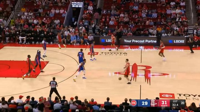

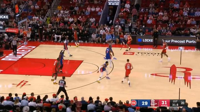

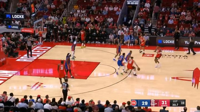

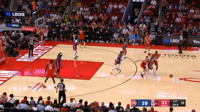

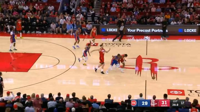

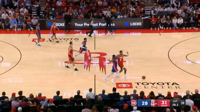

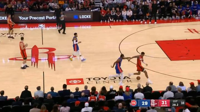

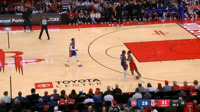

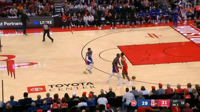


🎬 Sending 9 frames to Kimi K2.6 | Thinking: True



### 💬 Model Response

 I'll analyze this basketball game sequence frame by frame.

## (1) What is happening across the video timeline

This sequence captures a **turnover or stolen pass** during an NBA game between the Detroit Pistons (blue jerseys) and Houston Rockets (red jerseys). The timeline shows:
- Rockets initially have possession on offense
- A pass is intercepted or knocked away by a Pistons defender
- The Pistons player recovers the loose ball and initiates a fast break
- The sequence ends with the Pistons player dribbling across half-court while a Rockets player attempts to defend

## (2) Key subjects and objects visible

| Element | Description |
|--------|-------------|
| **Teams** | Detroit Pistons (blue) vs. Houston Rockets (red) |
| **Score** | Rockets leading 31-29 |
| **Time** | ~32-28 seconds remaining in 1st quarter |
| **Court** | Toyota Center (Rockets' home court) |
| **Key players** | Rockets ball-handler (#0 initially), Pistons defender who steals/recovers ball (#5), Rockets player

In [10]:
# Cell B1: Upload a local video, extract frames, analyse with Kimi K2.6
from google.colab import files as colab_files

# ── CONFIG ─────────────────────────────────────────────────────────────────────
N_FRAMES   = 10     # number of frames to extract (more = richer analysis, more tokens)
MAX_DIM    = 720    # max pixel dimension per frame (keeps token cost reasonable)
PROMPT     = (
    f"You are analysing {N_FRAMES} evenly-spaced frames extracted from a video. "
    "Describe: (1) what is happening across the video timeline, "
    "(2) key subjects and objects visible, "
    "(3) how the scene evolves from first to last frame, "
    "(4) anything unusual or notable."
)
THINKING   = True
SHOW_FRAMES = True   # set False to skip frame preview (saves time)
# ──────────────────────────────────────────────────────────────────────────────

print("📁 Select a video file (MP4 / MOV / AVI recommended)...")
uploaded = colab_files.upload()

if not uploaded:
    print("⚠️  No file uploaded.")
else:
    fname = next(iter(uploaded))
    raw   = uploaded[fname]

    # Save to disk so OpenCV can open it
    tmp_path = f"/tmp/{fname}"
    with open(tmp_path, "wb") as f:
        f.write(raw)
    print(f"\n💾 Saved: {fname}  ({len(raw)/1024/1024:.2f} MB)")

    # Extract frames
    frames = extract_frames(tmp_path, n_frames=N_FRAMES, max_dim=MAX_DIM)

    if SHOW_FRAMES:
        preview_frames(frames)

    # Build prompt and send
    messages = build_video_messages(frames, PROMPT)

    print(f"\n🎬 Sending {len(frames)} frames to Kimi K2.6 | Thinking: {THINKING}\n")
    response = make_request(messages, thinking=THINKING, max_tokens=6000)
    print_response(response)

### B2 · Analyse a video from a direct download URL

In [9]:
# Cell B2: Download a video from URL, extract frames, analyse
# Works with any direct .mp4 link (Google Drive, HuggingFace, S3, etc.)

# ── CONFIG ─────────────────────────────────────────────────────────────────────
VIDEO_URL  = "https://huggingface.co/moonshotai/Kimi-K2.6/resolve/main/figures/demo_video.mp4"
N_FRAMES   = 12
MAX_DIM    = 720
PROMPT     = (
    f"You are analysing {N_FRAMES} evenly-spaced frames from a video. "
    "Give a detailed description of: "
    "(1) the overall scene and setting, "
    "(2) people or objects present, "
    "(3) actions or events happening, "
    "(4) how the video progresses across these frames."
)
THINKING    = True
SHOW_FRAMES = True
# ──────────────────────────────────────────────────────────────────────────────

# Download video
print(f"⬇️  Downloading video from:\n   {VIDEO_URL}")
r = requests.get(VIDEO_URL, timeout=120)
r.raise_for_status()
tmp_path = "/tmp/downloaded_video.mp4"
with open(tmp_path, "wb") as f:
    f.write(r.content)
print(f"✅ Downloaded: {len(r.content)/1024/1024:.2f} MB")

# Extract frames
frames = extract_frames(tmp_path, n_frames=N_FRAMES, max_dim=MAX_DIM)

if SHOW_FRAMES:
    preview_frames(frames)

# Analyse
messages = build_video_messages(frames, PROMPT)

print(f"\n🎬 Sending {len(frames)} frames to Kimi K2.6 | Thinking: {THINKING}\n")
response = make_request(messages, thinking=THINKING, max_tokens=6000)
print_response(response)

⬇️  Downloading video from:
   https://youtube.com/shorts/-gkV5bnI4tk?si=lZhBWHiUV9x29z2Y$0
✅ Downloaded: 1.52 MB


ValueError: Cannot open video: /tmp/downloaded_video.mp4

### B3 · Targeted frame analysis — ask specific questions about specific moments

📹 Duration: 15.0s | FPS: 30.0
  ✅ Frame at t=0s extracted
  ✅ Frame at t=2s extracted
  ✅ Frame at t=5s extracted
  ✅ Frame at t=8s extracted


**t = 0s**

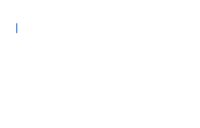

**t = 2s**

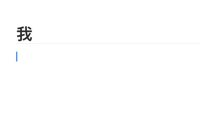

**t = 5s**

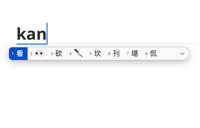

**t = 8s**

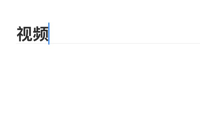


🎬 Sending targeted frames to Kimi K2.6 | Thinking: False



### 💬 Model Response

 I'll describe each frame based on the timestamps provided.

**t=0s:** A blank white document with a blinking blue cursor positioned on the left side. No text has been entered yet.

**t=2s:** The Chinese character "我" (meaning "I" or "me") appears in black text on the document. Below it is a blinking blue cursor on a new line. A thin gray horizontal line separates the first line from the second line where the cursor is positioned.

**t=5s:** The text "kan" appears in a text input field with a blue highlight box around it, indicating it's in an active editing state. Below this text is a Chinese input method candidate selection bar showing various character options numbered 1-8: 1) 看, 2) 👀 (eye emoji), 3) 砍, 4) 🔪 (knife emoji), 5) 坎, 6) 刊, 7) 堪, 8) 侃. The option "看" is highlighted in blue, indicating it's the currently selected suggestion.

**t=8s:** The Chinese characters "视频" (meaning "video") appear in black text on the document, with a blinking blue cursor positioned immediately afte

In [8]:
# Cell B3: Extract frames from specific timestamps and ask targeted questions
# Useful for: "what's happening at 0:05?", "is there text on screen at 0:12?"

# ── CONFIG ─────────────────────────────────────────────────────────────────────
VIDEO_PATH    = "/tmp/downloaded_video.mp4"   # reuses video from B2, or set your path
TIMESTAMPS_S  = [0, 2, 5, 8]                  # specific seconds to grab frames from
MAX_DIM       = 720
PROMPT        = "These frames were captured at specific timestamps. For each frame, describe exactly what is visible. Note any text, objects, or actions visible in each."
THINKING      = False    # instant mode fine here
# ──────────────────────────────────────────────────────────────────────────────

def extract_frames_at_timestamps(video_path: str, timestamps: list, max_dim: int = 720) -> list:
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total / fps
    print(f"📹 Duration: {duration:.1f}s | FPS: {fps:.1f}")

    frames = []
    for t in timestamps:
        frame_idx = int(t * fps)
        if frame_idx >= total:
            print(f"  ⚠️  t={t}s exceeds video length, skipping")
            continue
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = PILImage.fromarray(rgb)
        w, h = img.size
        if max(w, h) > max_dim:
            scale = max_dim / max(w, h)
            img   = img.resize((int(w*scale), int(h*scale)), PILImage.LANCZOS)
        frames.append((t, pil_to_b64(img, "JPEG")))
        print(f"  ✅ Frame at t={t}s extracted")

    cap.release()
    return frames

# Extract targeted frames
timestamped_frames = extract_frames_at_timestamps(VIDEO_PATH, TIMESTAMPS_S, MAX_DIM)

# Preview
for t, uri in timestamped_frames:
    b64data = uri.split(",", 1)[1]
    raw     = base64.b64decode(b64data)
    img     = PILImage.open(io.BytesIO(raw))
    display(Markdown(f"**t = {t}s**"))
    display(img.resize((200, int(img.height * 200 / img.width))))

# Build payload — include timestamp context in prompt
ts_list = ", ".join([f"t={t}s" for t, _ in timestamped_frames])
full_prompt = f"Frames captured at: [{ts_list}]. {PROMPT}"

content = [{"type": "text", "text": full_prompt}]
for _, uri in timestamped_frames:
    content.append({"type": "image_url", "image_url": {"url": uri}})

messages = [{"role": "user", "content": content}]

print(f"\n🎬 Sending targeted frames to Kimi K2.6 | Thinking: {THINKING}\n")
response = make_request(messages, thinking=THINKING, max_tokens=4096)
print_response(response, show_reasoning=False)

---
## 📋 Quick Reference

| Setting | Value |
|---|---|
| **API URL** | `https://integrate.api.nvidia.com/v1` |
| **Model string** | `moonshotai/kimi-k2.6` |
| **Key source** | [build.nvidia.com/moonshotai/kimi-k2.6](https://build.nvidia.com/moonshotai/kimi-k2.6) → free tier |
| **Thinking ON** | `THINKING = True` → temp 1.0, top_p 0.95 |
| **Thinking OFF** | `THINKING = False` → `extra_body={"chat_template_kwargs": {"thinking": false}}` |
| **Image formats** | GIF · JPG · JPEG · PNG |
| **Max images/req** | 4 (default NIM limit) |
| **Video method** | Frame extraction via OpenCV → send as images |
| **Context window** | 256K tokens |

### 💡 Tips
- For **short clips (<30s)**: 8–10 frames is plenty
- For **longer videos**: bump `N_FRAMES` to 15–20 and lower `MAX_DIM` to 480 to stay within token budget
- Use **B3 (targeted timestamps)** when you know which moments matter
- **Thinking mode** gives much richer reasoning — worth the extra seconds for analysis tasks
- You can mix images and video frames in one call — just add more `image_url` blocks to `content`